This notebook demonstrates how to use the pre-trained DNN models provided in this repository to approximate the stationary distribution of GI/G/K queues. No retraining is required. The code generates samples of interarrival and service moments and computes the corresponding stationary distributions using the following methods:
(i) QBD (exact); (ii) simulation; (iii) our DNN prediction; (iv) Whitt (1993); (v) Baron (2024) (applicable only to a continuous-time queue with a single server); and (vi) Sherzer (2025).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from Prediction.Comparison_and_validation import Compare_StatDist
from Training.Class_training import NN_for_Queue

Plot for saved stationary distribution example

In [2]:
# load saved stationary distribution example
K = 1 # number of servers: 1,2,3
rho = 0.66 # traffic intensity: 0.27,0.66,0.95
queue_type = 'continuous' # 'continuous', 'discrete', 'mixed'
df_dist = pd.read_csv(f'Output/samples/queue_length_sample/{queue_type.capitalize()}_Test_queue_length_sample_K{K}_rho_{rho}.csv')


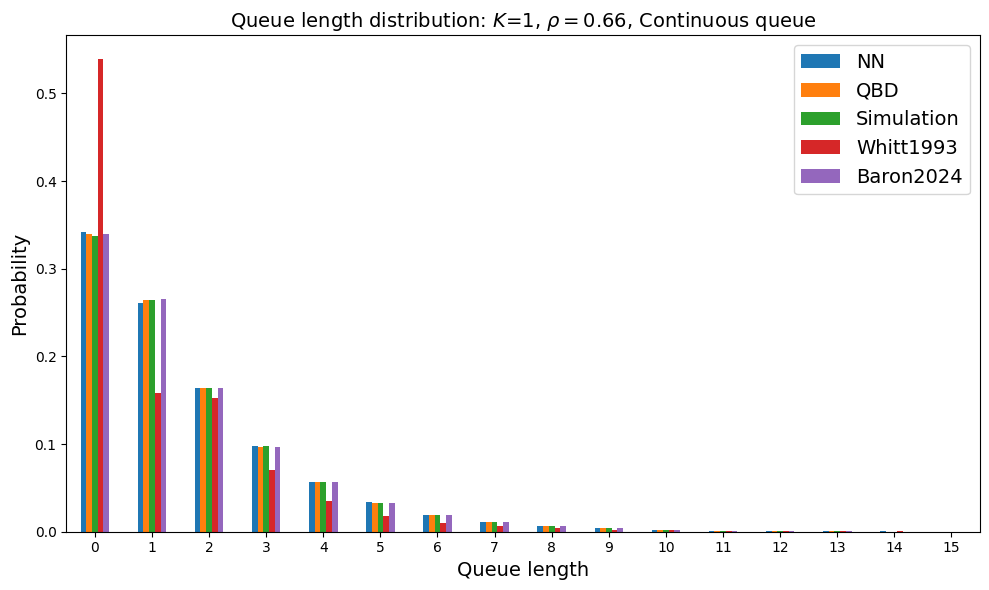

In [3]:
# Plotting the bar plot
N = int(rho*100/4)
df_dist.iloc[0:N,].plot(kind='bar', figsize=(10, 6), rot=0)

# Adding title and labels
plt.title(f'Queue length distribution: $K$={K}, $\\rho = {rho}$, {queue_type.capitalize()} queue', fontsize=14)
plt.xlabel('Queue length', fontsize=14)
plt.ylabel('Probability', fontsize=14)
# Rotating x-axis labels for better visibility
#plt.xticks(rotation=90)
# Adding legend
plt.legend(fontsize=14) # title='Methods'
# Adjust layout
plt.tight_layout()
# Displaying the plot
plt.show()

Prediction for a new generated random sample

In [4]:
# Parameters
n_max = 10           # The highest order of moments
Lmax = 500           # The maximum queue length + 1 (The maximum queue length is 499)
m_max = 15          # The maximum order of PH-representation (alpha, T)
input_dim = 2*n_max  # DNN input dimension: arrival n_max + service n_max

# User-defined parameters
K = 2                 # Number of servers: 1, 2, or 3
rho = 0.27           # Traffic intensity (0 < rho < 1)
queue_type = 'mixed'  # Queue type: 'continuous', 'discrete', or 'mixed'

# If the queue type is set to 'mixed', randomly select
# either a continuous-time or discrete-time queue with equal probability
Q_type = None
if queue_type == 'mixed':
    rnd_value = np.random.rand()
    if rnd_value < 0.5:
        queue_type = 'continuous'
    else:
        queue_type = 'discrete'
    Q_type = 'mixed'


In [5]:
# Load trained DNN model
DNN_net = NN_for_Queue(
    queue_type=queue_type, n_max=n_max, Lmax=Lmax, m_max=m_max, input_dim=input_dim, num_classes=Lmax
)
DNN_model = DNN_net.DNN()

DNN_model.load_weights(f'Output/models/model_GIGK({str(K)})_CSFP_saved_{queue_type}.weights.h5')

The queue type is discrete


/opt/anaconda3/envs/NN_paper/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [6]:
rho_lower = rho   # Lower bound for traffic intensity in sample generation
rho_upper = rho   # Upper bound for traffic intensity in sample generation

# Generate a random sample and predict its stationary distribution using the DNN model
# and several other methods
df_sample, _ = Compare_StatDist(queue_type, K, m_max, n_max, Lmax, DNN_model, rho_lower, rho_upper, max_moment_bound = 1.0e+30)

# Restore the original queue type setting if it was 'mixed'
if Q_type == 'mixed':
    queue_type = Q_type

queue type: discrete
D: Sample j = 1 with (K = 2 ma = 8 and ms = 14 ) of a total of 1 samples.
Iteration number for R (with R size =  840 ) =  277
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
SCV: 0.9051659844274615 0.9087981439983812
alpha: 0.527
inter_arrival_moms [ 1.          1.90516598  5.42877867 20.62112211 97.90948213]
tensor([[ 0.0000,  0.6446,  1.6917,  3.0263,  4.5840, -0.6162, -0.5859, -0.1511,
          0.5713,  1.5169,  2.0000]], dtype=torch.float64)


In [7]:
# Print the generated sample's stationary distribution based on different methods
df_sample

,DNN,QBD,Simulation,S(2025),W(1993)
0,5.639840e-01,5.687734e-01,0.569587,5.692294e-01,0.583608
1,3.233892e-01,3.224531e-01,0.321840,3.233916e-01,0.307561
2,8.641962e-02,8.388450e-02,0.083806,8.249250e-02,0.081042
3,2.013581e-02,1.919608e-02,0.019267,1.878678e-02,0.022649
4,4.665249e-03,4.390756e-03,0.004191,4.373163e-03,0.004189
...,...,...,...,...,...
495,4.404699e-29,1.165721e-317,0.000000,1.847234e-09,0.000000
496,5.495053e-29,2.541508e-318,0.000000,1.847174e-09,0.000000
497,3.824009e-29,1.318414e-319,0.000000,1.847231e-09,0.000000
498,1.065237e-28,0.000000e+00,0.000000,1.847107e-09,0.000000


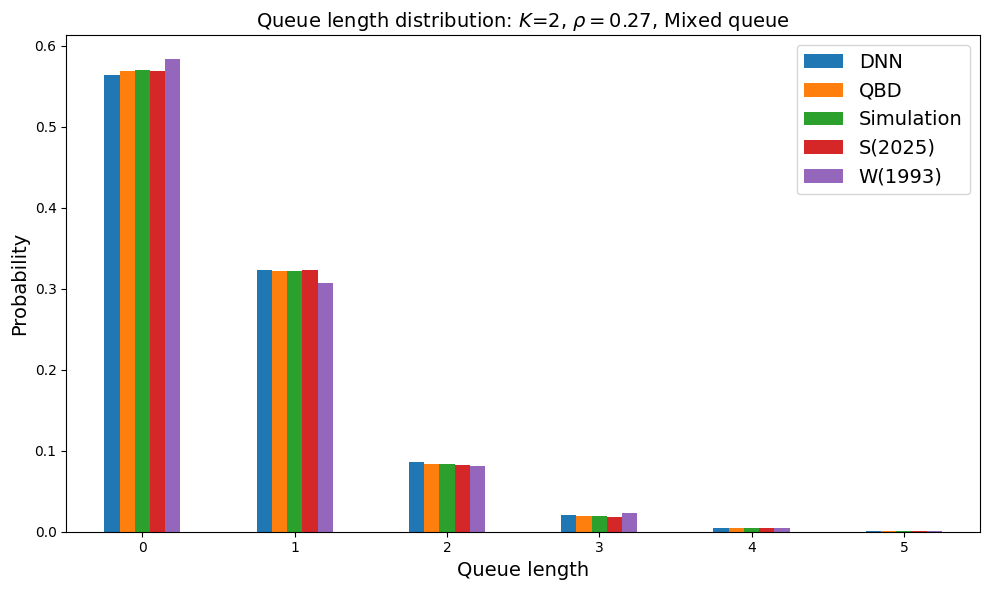

In [8]:
# Plotting the bar plot
N = int(rho*100/4) # number of bars to plot
df_sample.iloc[0:N,].plot(kind='bar', figsize=(10, 6), rot=0)

# Adding title and labels
plt.title(f'Queue length distribution: $K$={K}, $\\rho = {rho}$, {queue_type.capitalize()} queue', fontsize=14)
plt.xlabel('Queue length', fontsize=14)
plt.ylabel('Probability', fontsize=14)
# Rotating x-axis labels for better visibility
#plt.xticks(rotation=90)
# Adding legend
plt.legend(fontsize=14) # title='Methods'
# Adjust layout
plt.tight_layout()
# Displaying the plot
plt.show()